# Using the library

In this tutorial, we will show how to use the library to load the data and make some customized plots. We first import the relevant functions and variables from the library and check what limits and theories are available.

In [1]:
from eor_limits import (
    KNOWN_LIMITS,
    KNOWN_THEORIES,
    get_latex_label,
    load_limit_data,
    load_theory_model,
    plot_vs_k,
    plot_vs_z,
)

# KNOWN_LIMITS and KNOWN_THEORIES are both dictionaries with the keys being the names
# of the limits and theories and the values being the corresponding to its file paths
# (The paths are mostly for internal use but provide transparency on data storage)

print("* Available limits:", list(KNOWN_LIMITS.keys()))
print("* Available theories:", list(KNOWN_THEORIES.keys()))

* Available limits: ['Acharya2024', 'Barry2019', 'Beardsley2016', 'Dillon2014', 'Dillon2015', 'Eastwood2019', 'Ewall-Wice2016', 'Garsden2021', 'Gehlot2019', 'Gehlot2020', 'HERA2022', 'HERA2023', 'HERA2026', 'Kolopanis2019', 'Li2019', 'Mertens2020', 'Mertens2025', 'Munshi2024', 'Munshi2025', 'Nunhokee2025', 'Paciga2013', 'Pal2021', 'Parsons2014', 'Patil2017', 'Rahimi2021', 'Trott2020', 'Trott2025', 'Wilensky2023', 'Yoshiura2021']
* Available theories: ['Mesinger2016Faint', 'Mesinger2016Bright', 'Munoz2018FDM3', 'Munoz2022AllGalaxies', 'Munoz2022Optimistic', 'PaganoLiu2020Beta1.00', 'PaganoLiu2020Beta0.84', 'PaganoLiu2020Beta0.76', 'PaganoLiu2020Beta0.68', 'PaganoLiu2020Beta0.36', 'PaganoLiu2020Beta0.00', 'PaganoLiu2020Beta-0.36', 'PaganoLiu2020Beta-0.68', 'PaganoLiu2020Beta-0.76', 'PaganoLiu2020Beta-0.84', 'PaganoLiu2020Beta-1.00']


## Looking at the data

Let's import the latest HERA limits and see what they look like! The limits are stored as a `DataSet` object, which contains both the metadata — telescope, author, year and DOI — and a `Data` object with the following attributes:
- `z`: a 1D numpy array of the redshift bins.
- `k`: a tuple of 1D numpy arrays of the $k$-bins for each redshift bin.
- `delta_squared`: a tuple of 1D numpy arrays of the $\Delta_{21}^2$ limits for each redshift bin.

alongside other attributes such as `z_lower`, `z_upper`, `k_lower`, `k_upper` for the bin edges (if available). 

A useful method of the `Data` object is `as_pandas_df()`, which converts the data into a pandas DataFrame for nicer display. The rows of the pandas DataFrame are indexed by the redshift bins, and each contain the $k$-bins and $\Delta_{21}^2$ limits for that redshift bin.

In [2]:
hera2026 = load_limit_data("HERA2026")  # or eor_limits.DataSet.load("HERA2026")
print("Telescope:", hera2026.telescope)
print("Author:", hera2026.author)
print("Year:", hera2026.year)
print("DOI:", hera2026.doi)
print("Data:")
hera2026.data.as_pandas_df()

Telescope: HERA
Author: HERA
Year: 2026
DOI: 10.3847/1538-4357/ae2d54
Data:


,z,z_lower,z_upper,z_tags,k,k_lower,k_upper,delta_squared
0,24.37,None,None,,"[0.3, 0.41, 0.52, 0.63, 0.74, 0.85, 0.96, 1.07...",None,None,"[119241794.0, 18126332.0, 11485811.0, 22626477..."
1,19.80,None,None,,"[0.25, 0.4, 0.54, 0.69, 0.83, 0.98, 1.12, 1.26...",None,None,"[79776026.0, 15352970.0, 11126866.0, 19649308...."
2,16.78,None,None,,"[0.25, 0.4, 0.55, 0.69, 0.84, 0.98, 1.13, 1.27...",None,None,"[19250710.0, 1790281.0, 1130584.0, 1751430.0, ..."
3,10.76,None,None,,"[0.48, 0.76, 1.03, 1.31, 1.58, 1.86]",None,None,"[173355.0, 46285.0, 82409.0, 152436.0, 347587...."
4,9.87,None,None,,"[0.33, 0.51, 0.7, 0.89, 1.07, 1.26, 1.44, 1.63...",None,None,"[514562.0, 30328.0, 35364.0, 31048.0, 48586.0,..."
5,7.63,None,None,,"[0.37, 0.59, 0.8, 1.02, 1.23, 1.45, 1.66, 1.87...",None,None,"[18187.0, 3113.0, 4776.0, 18291.0, 18777.0, 23..."
6,7.05,None,None,,"[0.44, 0.7, 0.95, 1.21, 1.46, 1.71, 1.97, 2.22]",None,None,"[3513.0, 1775.0, 5514.0, 9699.0, 19014.0, 4739..."
7,5.56,None,None,,"[0.55, 0.87, 1.18, 1.5, 1.81, 2.13, 2.44]",None,None,"[2058.0, 1428.0, 4433.0, 5394.0, 8869.0, 18086..."


## Slicing the data

The library allows you to do cuts on the data, which can be quite useful for comparing datasets. There are six main functions:
- `select_closest_z(z_target)`: selects the redshift bin closest to the input $z$.
- `select_closest_k(k_target)`: selects the $k$-bin closest to the input $k$.
- `select_z_range(z_min, z_max)`: selects the redshift bins in the range $z_\mathrm{min} \leq z \leq z_\mathrm{max}$.
- `select_k_range(k_min, k_max)`: selects the $k$-bins in the range $k_\mathrm{min} \leq k \leq k_\mathrm{max}$.
- `select_delta_squared_range(delta_squared_min, delta_squared_max)`: selects the limits in the range $\Delta_{21,\mathrm{min}}^2 \leq \Delta_{21}^2 \leq \Delta_{21,\mathrm{max}}^2$.
- `select_lowest_delta_squared(per_z=True, per_tag=False)`: selects the lowest limits. `per_z` and `per_tag` are boolean flags that control how the lowest limits are selected (i.e. across redshift bins and/or across tags).

Let's do some cuts on the data to select only the limits in the range $z=7-10$ and $k=0.1-1$ h/Mpc.

In [3]:
hera2026_trunc = hera2026.select_z_range(7, 10).select_k_range(0.1, 1)
hera2026_trunc.data.as_pandas_df()

,z,z_lower,z_upper,z_tags,k,k_lower,k_upper,delta_squared
0,9.87,None,None,,"[0.33, 0.51, 0.7, 0.89]",None,None,"[514562.0, 30328.0, 35364.0, 31048.0]"
1,7.63,None,None,,"[0.37, 0.59, 0.8]",None,None,"[18187.0, 3113.0, 4776.0]"
2,7.05,None,None,,"[0.44, 0.7, 0.95]",None,None,"[3513.0, 1775.0, 5514.0]"


What about looking at a specific $k$-bin or $z$-bin? Let's try selecting the redshift bin closest to $z=7$ and also, separately, the $k$-bin closest to $k=0.1$ h/Mpc.

In [4]:
hera2026_z7 = hera2026.select_closest_z(7)
hera2026_z7.data.as_pandas_df()

,z,z_lower,z_upper,z_tags,k,k_lower,k_upper,delta_squared
0,7.05,None,None,,"[0.44, 0.7, 0.95, 1.21, 1.46, 1.71, 1.97, 2.22]",None,None,"[3513.0, 1775.0, 5514.0, 9699.0, 19014.0, 4739..."


In [5]:
hera2026_k01 = hera2026.select_closest_k(0.1)
hera2026_k01.data.as_pandas_df()

,z,z_lower,z_upper,z_tags,k,k_lower,k_upper,delta_squared
0,24.37,None,None,,[0.3],None,None,[119241794.0]
1,19.80,None,None,,[0.25],None,None,[79776026.0]
2,16.78,None,None,,[0.25],None,None,[19250710.0]
3,10.76,None,None,,[0.48],None,None,[173355.0]
4,9.87,None,None,,[0.33],None,None,[514562.0]
5,7.63,None,None,,[0.37],None,None,[18187.0]
6,7.05,None,None,,[0.44],None,None,[3513.0]
7,5.56,None,None,,[0.55],None,None,[2058.0]


## Custom plotting

Let's plot the limits, now including other HERA limits and some theoretical models for comparison. The theory models are loaded in the same manner as the limits so we can filter and plot them all together as shown in the next cell.

/tmp/ipykernel_107787/262335659.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


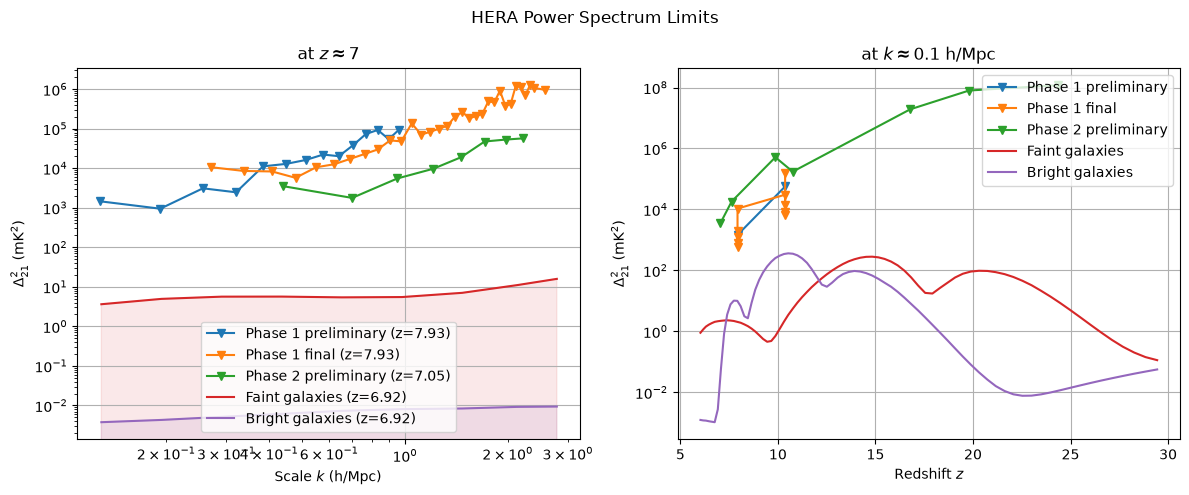

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

datasets = [
    load_limit_data("HERA2022"),
    load_limit_data("HERA2023"),
    load_limit_data("HERA2026"),
    load_theory_model("Mesinger2016Faint"),
    load_theory_model("Mesinger2016Bright"),
]
labels = [
    "Phase 1 preliminary",
    "Phase 1 final",
    "Phase 2 preliminary",
    "Faint galaxies",
    "Bright galaxies",
]
colors = ["C0", "C1", "C2", "C3", "C4"]
markers = ["v", "v", "v", "none", "none"]

for dataset, label, color, marker in zip(
    datasets, labels, colors, markers, strict=True
):
    # Plotting the limits for the redshift bin closest to z=7
    # (k range included to limit the theory models to the data range)
    data_z7 = dataset.select_closest_z(7).select_k_range(1e-1, 5).data
    ax1.plot(
        data_z7.k[0],
        data_z7.delta_squared[0],
        marker=marker,
        color=color,
        label=label + f" (z={data_z7.z[0]:.2f})",
    )

    # Plotting the limits for the k-bin closest to k=0.1 h/Mpc
    # (z range included to limit the theory models to the data range)
    data_k02 = dataset.select_closest_k(0.1).select_z_range(6, 30).data
    ax2.plot(
        data_k02.z, data_k02.delta_squared, marker=marker, color=color, label=label
    )

    # Some shading for the theory models
    if "galaxies" in label:
        ax1.fill_between(data_z7.k[0], data_z7.delta_squared[0], alpha=0.1, color=color)

# Some plot formatting
ax1.set_title(r"at $z \approx 7$")
ax1.set_xlabel(r"Scale $k$ (h/Mpc)")
ax1.set_xscale("log")
ax2.set_title(r"at $k \approx 0.1$ h/Mpc")
ax2.set_xlabel(r"Redshift $z$")
ax1.legend()
ax2.legend()
for ax in [ax1, ax2]:
    ax.set_ylabel(r"$\Delta_{21}^2$ (mK$^2$)")
    ax.set_yscale("log")
    ax.grid()

fig.suptitle("HERA Power Spectrum Limits")
fig.tight_layout()
fig.show()

## In-built plotting

### Plot vs k

A similar plot can be made using the in-built plotting function `plot_vs_k()`, which takes care of all the slicing and styling for you. This plot differs slightly, in that we are not making narrow selection cuts but plotting all the data within $z=7-8$ coloured by redshift bins.

/tmp/ipykernel_107787/1495345478.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


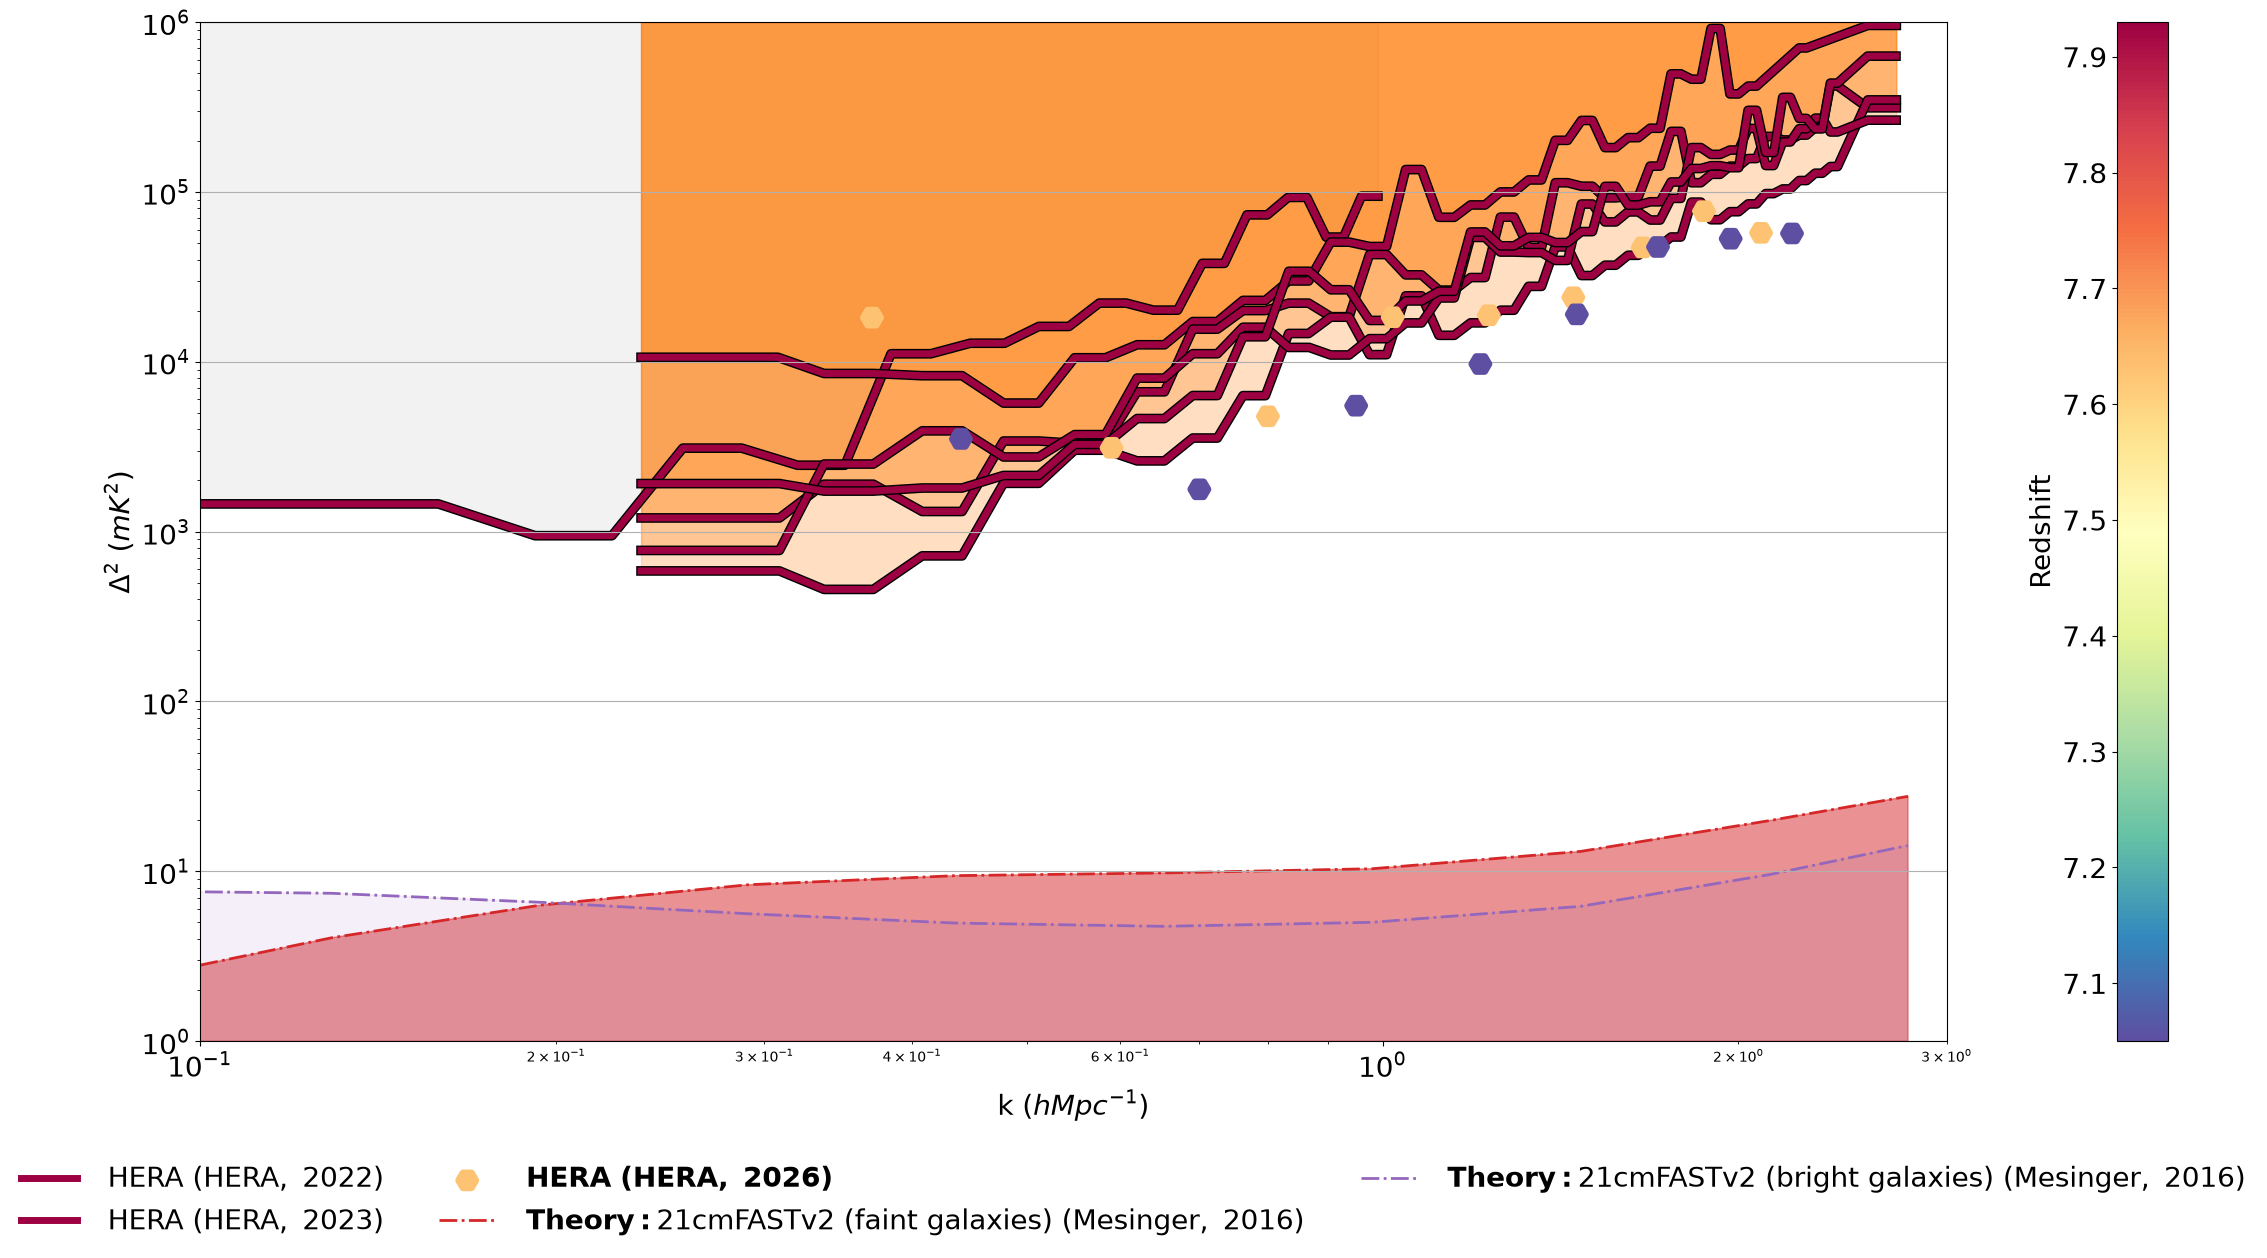

In [7]:
fig = plot_vs_k(
    limits=["HERA2022", "HERA2023", "HERA2026"],
    bold_limits=["HERA2026"],
    shade_limits=True,
    base_limit_style={"linewidth": 5, "shade_alpha": 0.1},
    limit_styles={"HERA2023": {"shade_alpha": 0.25, "shade_color": "C1"}},
    theories=["Mesinger2016Faint", "Mesinger2016Bright"],
    shade_theories=True,
    base_theory_style={"linestyle": "-."},
    theory_styles={
        "Mesinger2016Faint": {"color": "C3", "shade_alpha": 0.5, "shade_color": "C3"},
        "Mesinger2016Bright": {"color": "C4", "shade_alpha": 0.1, "shade_color": "C4"},
    },
    z_range=(7, 8),
    fontsize=20,
    fig_ratio=0.5,
)
fig.show()

### Plot vs redshift

You can also plot the lowest upper limit from each experiment for any $k$ as a function
of redshift. There are many options to play with in terms of styling. The following
example shows a few of these, including adding theoretical models, and adjusting
the style of some of the papers:

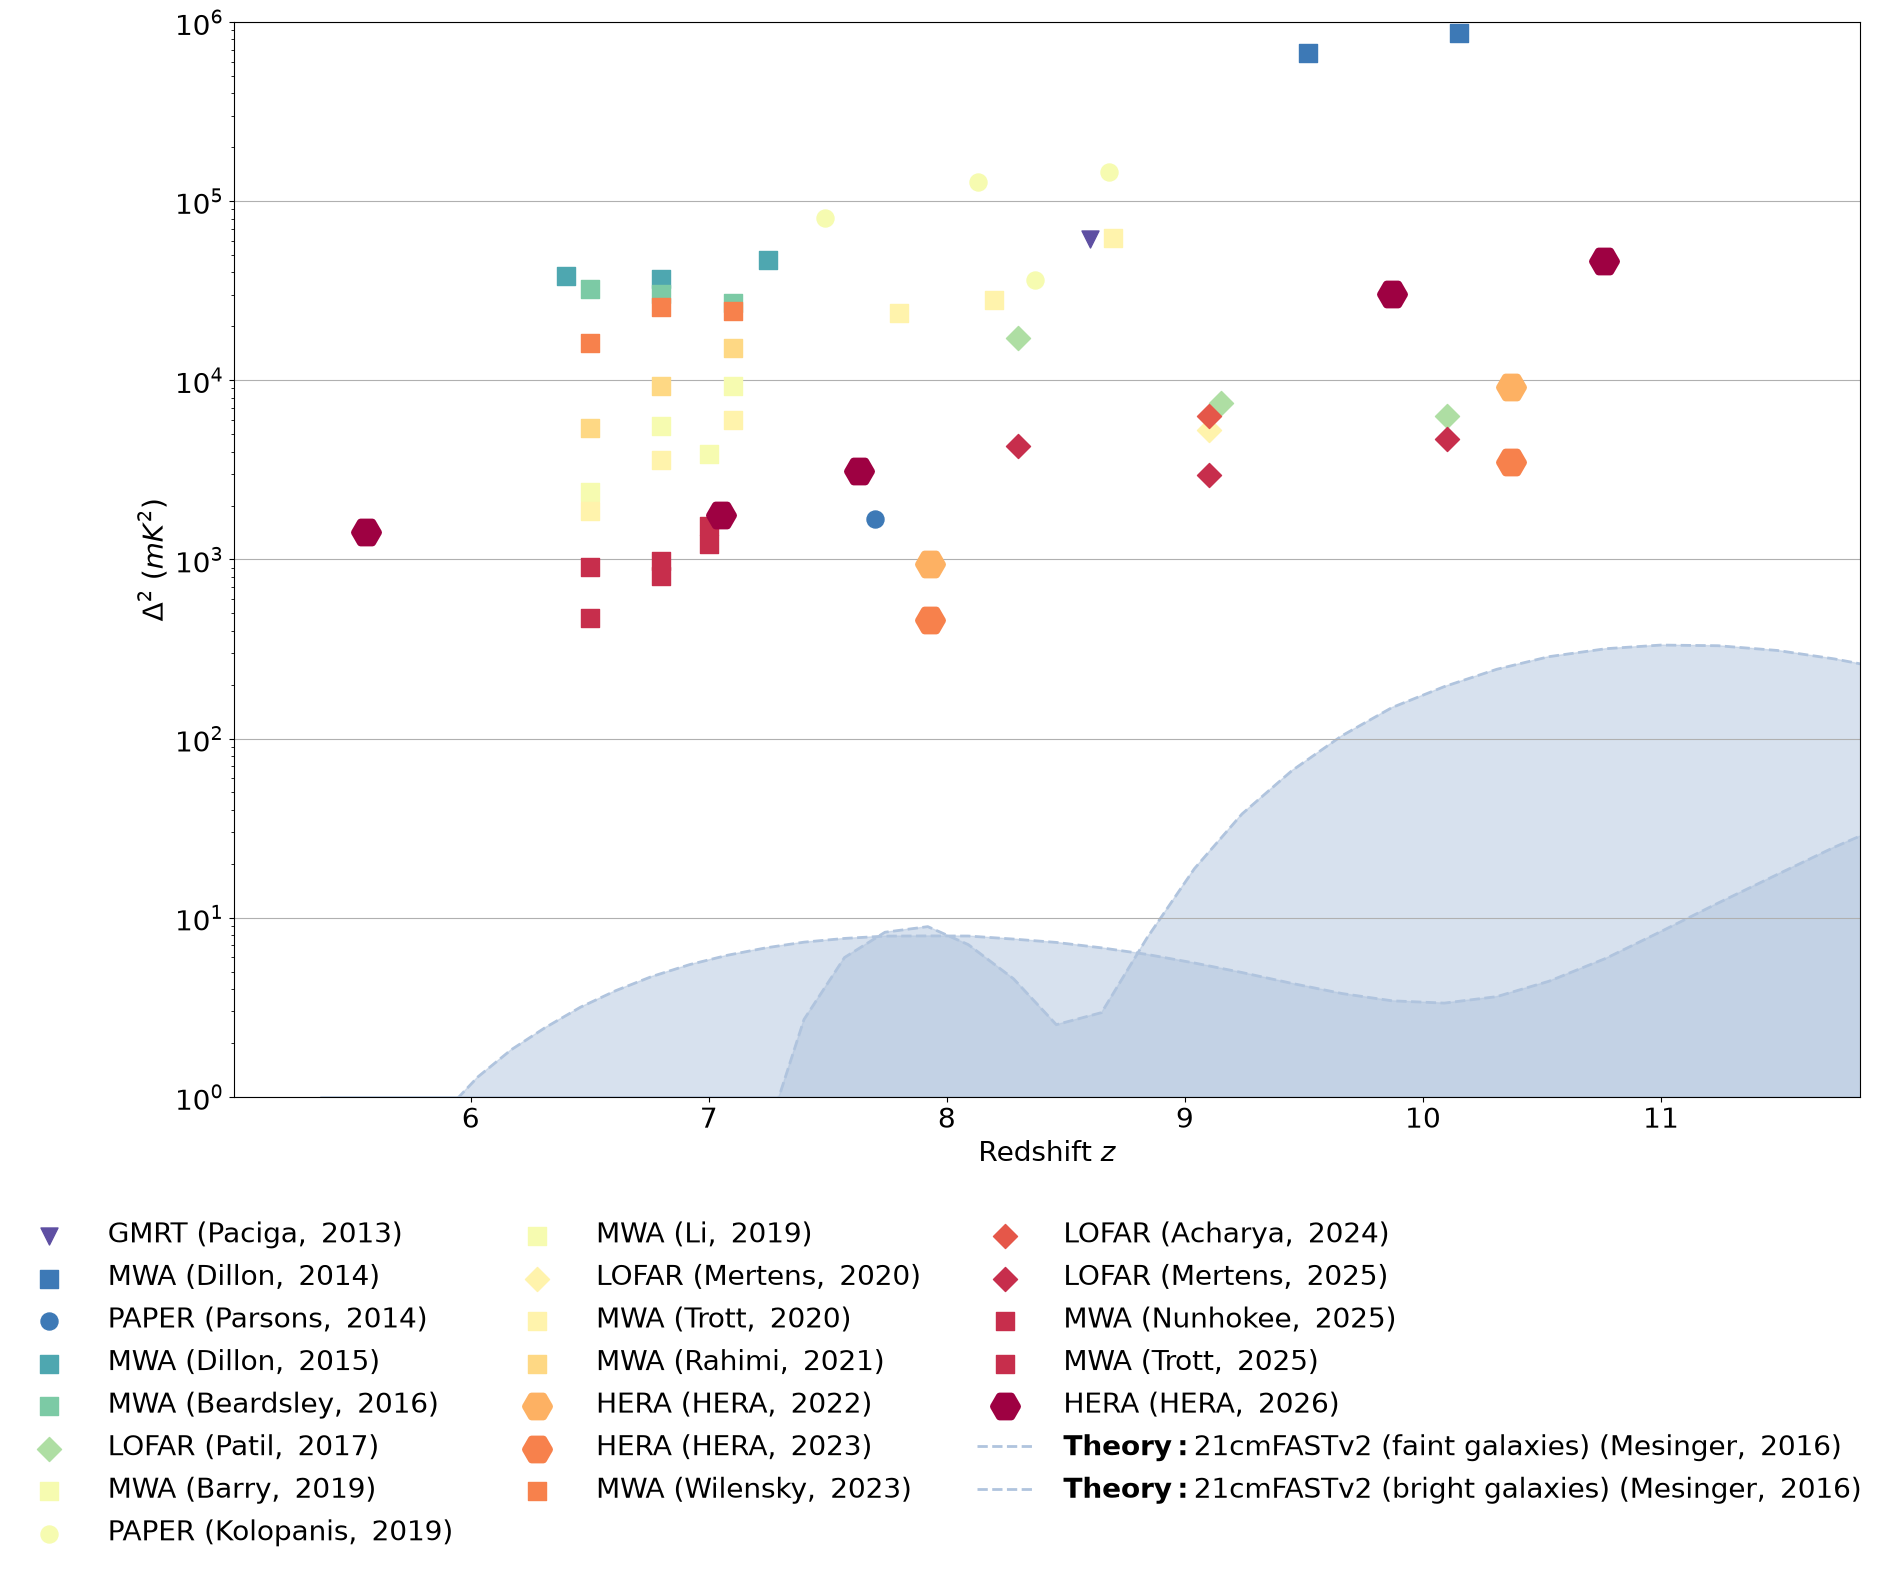

In [5]:
plot_vs_z(
    fig_width=20.0,
    fontsize=20,
    leg_cols=3,
    theories=["Mesinger2016Faint", "Mesinger2016Bright"],
    z_range=(5.5, 15),
    limit_styles={
        "HERA2022": {"s": 300, "linewidth": 5},
        "HERA2023": {"s": 300, "linewidth": 5},
        "HERA2026": {"s": 300, "linewidth": 5},
    },
);

Perhaps you need to really accentuate a particular set of observations. You can achieve
something like this:

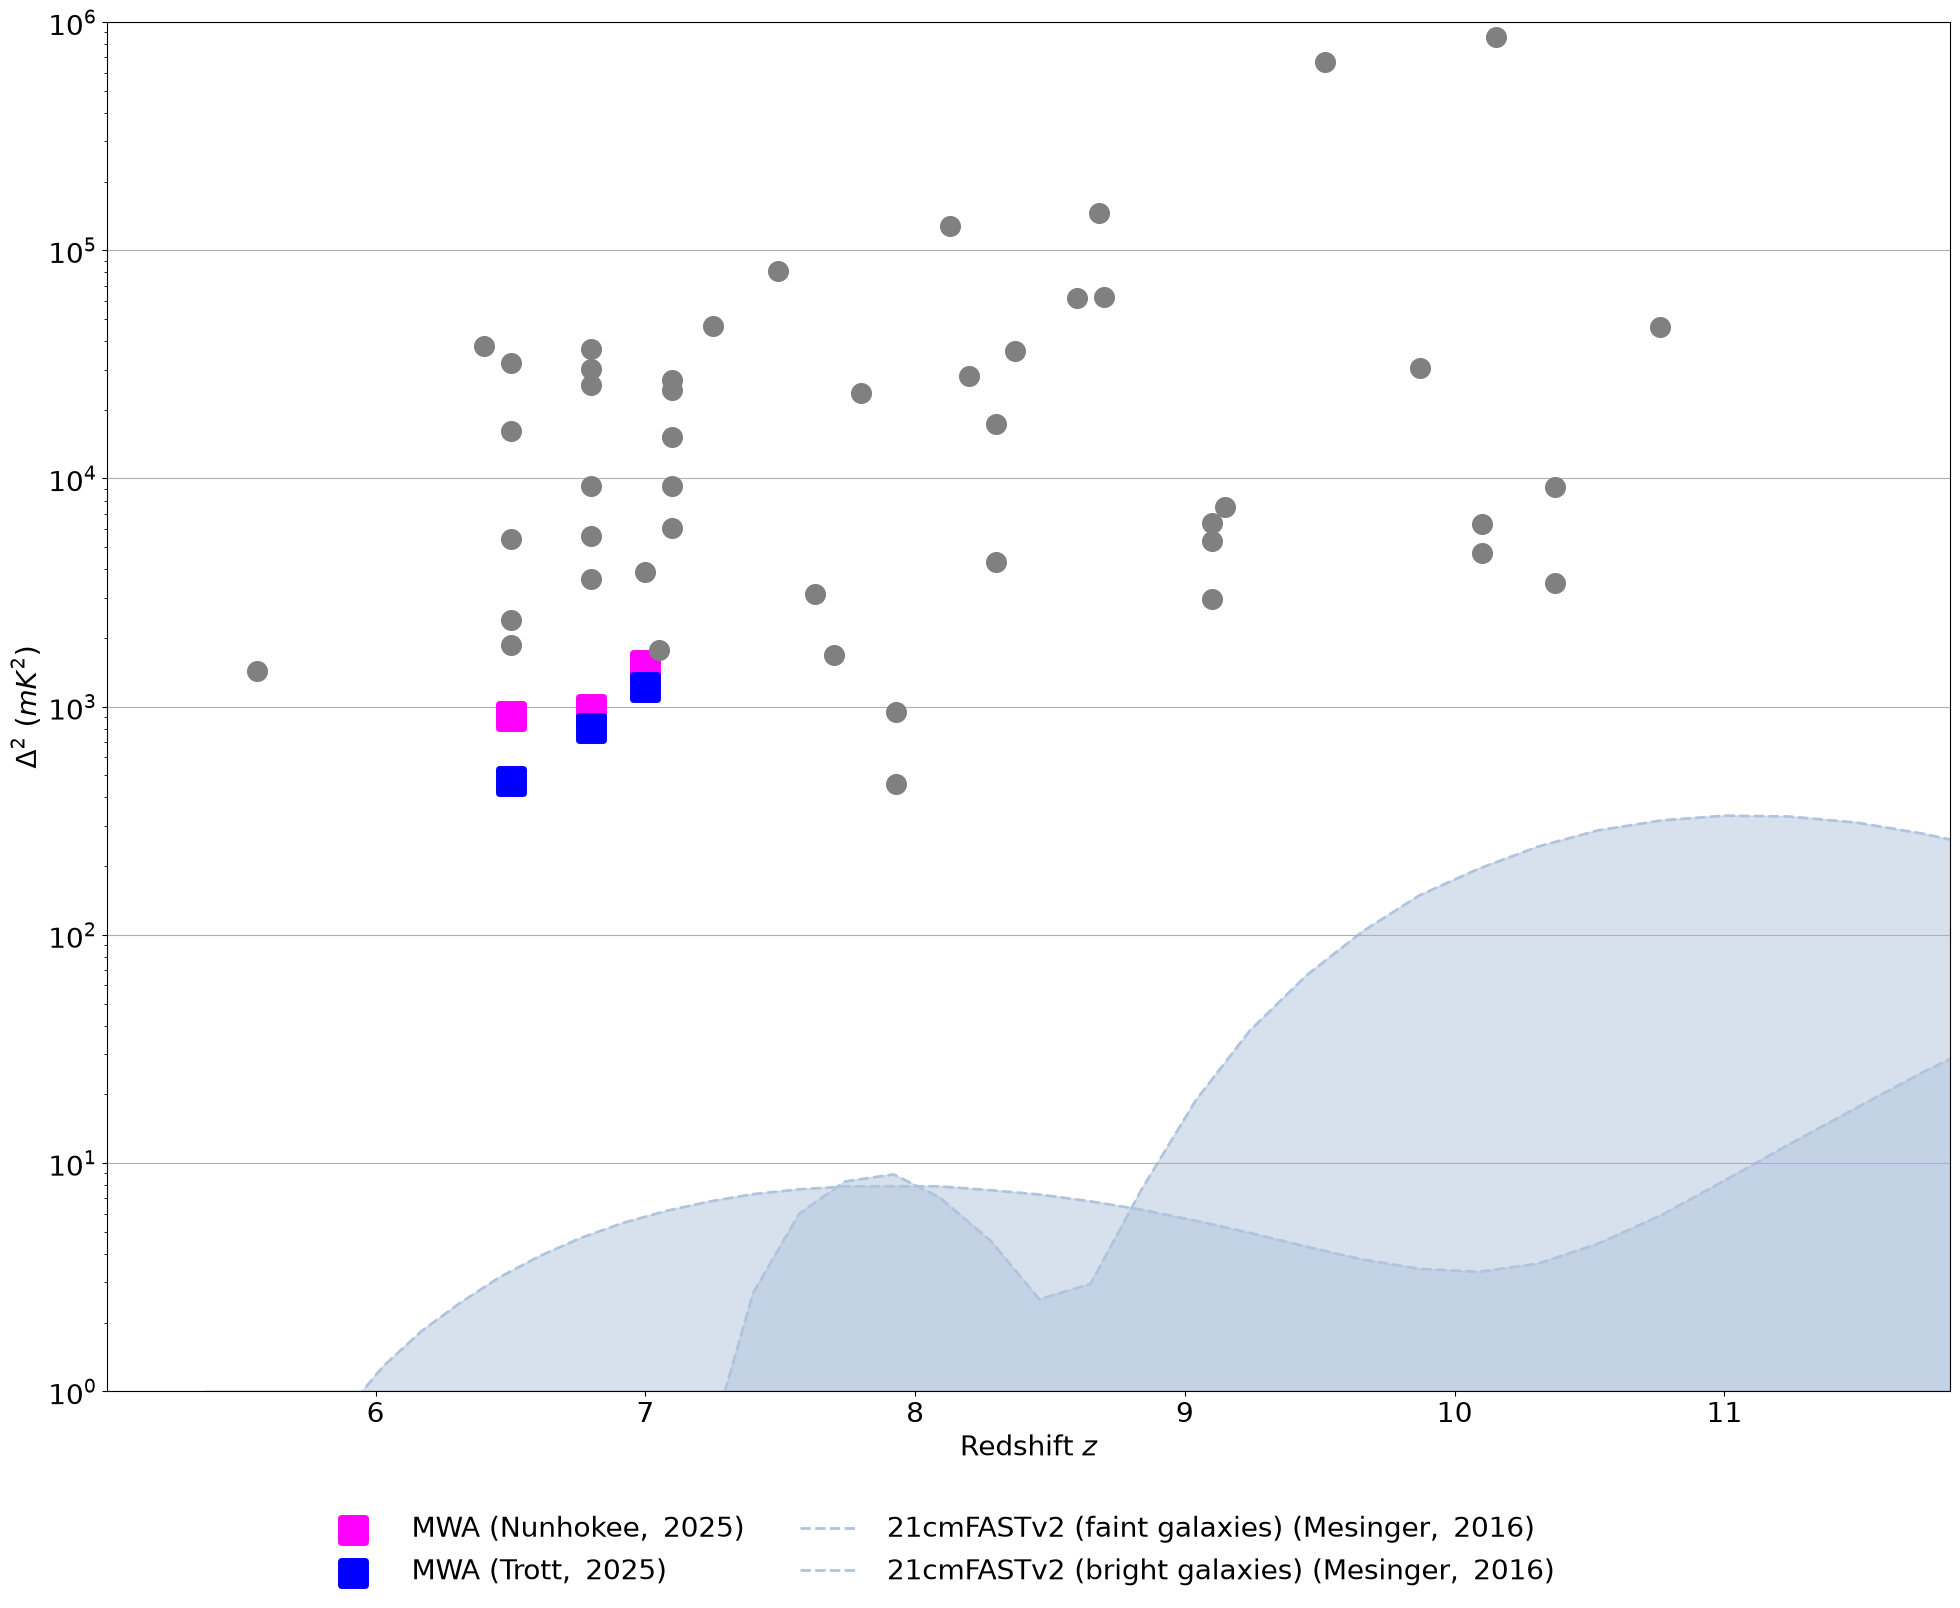

In [ ]:
def label_only_recent_mwa(limit):
    if (limit.telescope == "MWA" and limit.year >= 2024) or "Mesinger" in limit.key:
        return get_latex_label(limit)
    return None


plot_vs_z(
    fig_width=20.0,
    fontsize=20,
    leg_cols=2,
    theories=["Mesinger2016Faint", "Mesinger2016Bright"],
    z_range=(5.5, 15),
    base_limit_style={"s": 200, "marker": "o", "color": "gray"},
    limit_styles={
        "Nunhokee2025": {"s": 300, "linewidth": 5, "marker": "s", "color": "magenta"},
        "Trott2025": {"s": 300, "linewidth": 5, "marker": "s", "color": "blue"},
    },
    legend_labeler=label_only_recent_mwa,
);